# Projeto Prático: Machine Learning & Inteligência de Mercado
## Análise Estratégica da Concentração no Comércio Global de Bens Criativos (Dataset OpenFCS)

---

> **Componente Curricular:** Machine Learning aplicado à Administração
> **Instituição:** Curso de Graduação em Administração
> **Objetivo:** Aplicação prática de Ciência de Dados, Machine Learning e Inteligência Artificial Generativa para diagnosticar padrões de concentração e (re)configuração competitiva no comércio mundial de bens criativos, a partir do acervo aberto OpenFCS (UNCTAD, alinhado ao UNESCO Framework for Cultural Statistics 2025).

---

### Corpo Docente & Contato

| Atributo | Detalhes |
| :--- | :--- |
| **Professor** | **Sérgio Assunção Monteiro, D.Sc.** |
| **Conecte-se no LinkedIn** | [🌐 linkedin.com/in/sergio-assunção-monteiro](https://www.linkedin.com/in/sergio-assun%C3%A7%C3%A3o-monteiro-b781897b/) |
| **Currículo Lattes** | [🔬 lattes.cnpq.br/9489191035734025](http://lattes.cnpq.br/9489191035734025) |
| **Repositório GitHub** | [💻 github.com/sergiomonteiro76](https://github.com/sergiomonteiro76) |

---

### Sobre este Notebook
Este ambiente foi configurado para que os alunos atuem como **Analistas de Inteligência de Mercado**. Ao longo do semestre, com apoio de modelos de linguagem (IA) integrados ao ecossistema do Google Colab, vamos reconstruir — do dado bruto ao modelo preditivo — o diagnóstico de estrutura competitiva de um setor econômico real: o comércio internacional de bens criativos.

* **Fonte de dados:** [OpenFCS Dataset](https://doi.org/10.5281/zenodo.21211053) — Monteiro & Dubeux (2026), CC-BY-4.0.
* **Material de apoio:** Capítulos 1 a 3 das notas de aula (Ambiente e primeiro contato; Python/pandas/NumPy; Bases de Dados e SQL).

## Aula 6 — Correlação, Testes de Hipótese e o Teorema Central do Limite
A Aula 5 mostrou que os valores de exportação são extremamente assimétricos. Hoje damos o próximo passo: construir a primeira métrica de concentração de mercado (o índice HHI), testar se ela se relaciona com o descritor estrutural do artigo original (Ξ, a razão espectral), e formalizar isso tudo com testes de hipótese — incluindo uma demonstração ao vivo do Teorema Central do Limite.

recarregar o acervo

In [1]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np

url = (
    "https://zenodo.org/records/21211053/files/"
    "openfcs_v1.0.0.zip?download=1"
)
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("openfcs")

endereco = "openfcs/openfcs-1.0.0/data/derived/"
edges = pd.read_csv(endereco + "trade_edges.csv")
edges7 = edges[edges["resolution"] == "cer7"].copy()

print(f"edges7: {len(edges7):,} linhas")   # deve dar 1.026.400

edges7: 1,026,400 linhas


### 6.1 Construindo o índice HHI, passo a passo
O HHI mede concentração de mercado: soma das participações de cada exportador ao quadrado, dentro de cada domínio-ano. Como `edges7` tem uma linha por par (exportador, parceiro), o primeiro passo é agregar por exportador antes de calcular participação — senão contamos o mesmo exportador várias vezes (uma por parceiro).

In [2]:
exportador_dominio_ano = (
    edges7.groupby(["fcs_domain", "year", "economy"])["value_usd_millions"]
    .sum()
    .reset_index(name="total_economia")
)
exportador_dominio_ano.head()

,fcs_domain,year,economy,total_economia
0,A. Cultural and natural heritage,2002,Andorra,0.002
1,A. Cultural and natural heritage,2002,Anguilla,0.013
2,A. Cultural and natural heritage,2002,Argentina,0.085
3,A. Cultural and natural heritage,2002,Armenia,0.000
4,A. Cultural and natural heritage,2002,Australia,13.718


participação de mercado e HHI

In [3]:
total_camada = exportador_dominio_ano.groupby(["fcs_domain", "year"])[
    "total_economia"
].transform("sum")

exportador_dominio_ano["participacao"] = (
    exportador_dominio_ano["total_economia"] / total_camada
)

hhi_por_dominio_ano = (
    exportador_dominio_ano.groupby(["fcs_domain", "year"])["participacao"]
    .apply(lambda s: (s ** 2).sum())
    .reset_index(name="HHI")
)
hhi_por_dominio_ano["exportadores_efetivos"] = 1 / hhi_por_dominio_ano["HHI"]
hhi_por_dominio_ano.sort_values("HHI", ascending=False).head(10)

,fcs_domain,year,HHI,exportadores_efetivos
1,A. Cultural and natural heritage,2003,0.404968,2.469331
0,A. Cultural and natural heritage,2002,0.307426,3.252814
122,F. Design and creative services,2009,0.306201,3.265834
121,F. Design and creative services,2008,0.290844,3.438264
120,F. Design and creative services,2007,0.260200,3.843192
2,A. Cultural and natural heritage,2004,0.259860,3.848228
3,A. Cultural and natural heritage,2005,0.259741,3.849990
4,A. Cultural and natural heritage,2006,0.219693,4.551813
119,F. Design and creative services,2006,0.216385,4.621395
128,F. Design and creative services,2015,0.205784,4.859468


### 6.2 HHI mediano por domínio: a Tabela 5.1 da apostila, recalculada por vocês

In [4]:
hhi_mediano_dominio = (
    hhi_por_dominio_ano.groupby("fcs_domain")["HHI"]
    .median()
    .sort_values(ascending=False)
)
print(hhi_mediano_dominio)
print("\nNumero efetivo de exportadores (1/HHI mediano):")
print(1 / hhi_mediano_dominio)

fcs_domain
A. Cultural and natural heritage                   0.161872
C. Visual arts (crafts) / F. Design                0.153186
F. Design and creative services                    0.114537
B. Performance and celebration / C. Visual arts    0.114305
E. Audiovisual and interactive media               0.102964
D. Books and press                                 0.064927
Name: HHI, dtype: float64

Numero efetivo de exportadores (1/HHI mediano):
fcs_domain
A. Cultural and natural heritage                    6.177715
C. Visual arts (crafts) / F. Design                 6.528026
F. Design and creative services                     8.730791
B. Performance and celebration / C. Visual arts     8.748502
E. Audiovisual and interactive media                9.712145
D. Books and press                                 15.401958
Name: HHI, dtype: float64


### 6.3 Carregando spectral_results.csv — nunca assuma, inspecione
Este arquivo traz as medidas espectrais (Ξ = λ1/λ2) já calculadas pelos autores do acervo. Antes de usá-lo, vamos inspecionar suas colunas — a regra de ouro continua valendo.

In [5]:
spectral = pd.read_csv(endereco + "spectral_results.csv")
print(spectral.columns.tolist())
print(f"Linhas: {len(spectral):,}")
spectral.head()

['year', 'product', 'resolution', 'cer_code', 'fcs_domain', 'mapping_status', 'n_economies', 'n_edges', 'lambda1', 'lambda2_pos', 'lambda2_absmag', 'lambda_min', 'xi_standard', 'xi_v1_absmag', 'v1_used_negative_eig', 'spectral_entropy', 'lcc_fraction']
Linhas: 322


,year,product,resolution,cer_code,fcs_domain,mapping_status,n_economies,n_edges,lambda1,lambda2_pos,lambda2_absmag,lambda_min,xi_standard,xi_v1_absmag,v1_used_negative_eig,spectral_entropy,lcc_fraction
0,2002,Manufacturing of crafts and design goods,cer7,CER020,C. Visual arts (crafts) / F. Design,provisional_straddle,232,7775,30604.8101,5629.1829,-20833.9661,-20833.9661,5.436812,1.468986,True,1.085940,0.995690
1,2002,Carpets,craft_sub,CER020s,C. Visual arts (crafts) / F. Design,provisional,224,3157,1416.9553,754.9356,-1136.4157,-1136.4157,1.876922,1.246864,True,1.401629,0.991071
2,2002,Fashion accessories,craft_sub,CER020s,C. Visual arts (crafts) / F. Design,provisional,230,4881,7841.6429,1010.8474,-4717.5226,-4717.5226,7.757494,1.662237,True,0.900446,0.991304
3,2002,Interior,craft_sub,CER020s,C. Visual arts (crafts) / F. Design,provisional,231,6770,12424.3014,3070.9271,-9951.3675,-9951.3675,4.045782,1.248502,True,1.200670,0.995671
4,2002,Jewellery,craft_sub,CER020s,C. Visual arts (crafts) / F. Design,provisional,229,3486,5641.9207,874.0224,-3530.2433,-3530.2433,6.455121,1.598168,True,1.126123,0.995633


### 6.4 Replicando a Figura 1 do artigo: HHI mediano vs. Ξ mediano por domínio
Ajuste os nomes de coluna abaixo conforme o que apareceu na Célula 9.

In [7]:
coluna_dominio = "fcs_domain"
coluna_resolucao = "resolution"
coluna_xi = "xi_standard"

# Filtrar spectral por resolução 'cer7'
spectral7 = spectral[spectral[coluna_resolucao] == "cer7"].copy()

# Mesclar hhi_por_dominio_ano com spectral7
# 'HHI' está em hhi_por_dominio_ano, 'xi_standard' está em spectral7
# As colunas comuns para mesclagem são 'fcs_domain' e 'year'
merged_data = pd.merge(
    hhi_por_dominio_ano,
    spectral7[[coluna_dominio, "year", coluna_xi]],
    on=[coluna_dominio, "year"],
    how="inner",
)

# Calcular a mediana do HHI e do Xi por domínio
resumo_espectral = (
    merged_data.groupby(coluna_dominio)[["HHI", coluna_xi]]
    .median()
    .reset_index()
)
resumo_espectral

,fcs_domain,HHI,xi_standard
0,A. Cultural and natural heritage,0.161872,8.885996
1,B. Performance and celebration / C. Visual arts,0.114305,6.489908
2,C. Visual arts (crafts) / F. Design,0.153186,7.467204
3,D. Books and press,0.064927,1.775818
4,E. Audiovisual and interactive media,0.102964,3.612509
5,F. Design and creative services,0.114537,3.121079


correlação de Spearman + significância — o self-check do artigo

In [9]:
from scipy import stats

coluna_hhi = "HHI"

rho, p_valor = stats.spearmanr(
    resumo_espectral[coluna_hhi], resumo_espectral[coluna_xi]
)
print(f"Correlacao de Spearman (rho): {rho:.2f}")
print(f"Valor-p: {p_valor:.2f}")
print("\nReferencia do artigo: rho = 0.68, p = 0.09")

Correlacao de Spearman (rho): 0.83
Valor-p: 0.04

Referencia do artigo: rho = 0.68, p = 0.09


### 6.5 Interpretando o valor-p: significativo ou não?

In [10]:
alfa = 0.05
if p_valor < alfa:
    print(f"p = {p_valor:.2f} < {alfa}: rejeitamos H0 (correlacao e significativa)")
else:
    print(f"p = {p_valor:.2f} >= {alfa}: nao rejeitamos H0 (correlacao NAO e significativa)")

print("\nH0: nao existe correlacao monotona entre HHI mediano e Xi mediano")
print("H1: existe correlacao monotona entre HHI mediano e Xi mediano")

p = 0.04 < 0.05: rejeitamos H0 (correlacao e significativa)

H0: nao existe correlacao monotona entre HHI mediano e Xi mediano
H1: existe correlacao monotona entre HHI mediano e Xi mediano


### 6.6 ANOVA: a concentração difere entre domínios?
Um teste F compara a variância *entre* grupos (domínios) com a variância *dentro* de cada grupo (anos). Usamos nosso próprio `hhi_por_dominio_ano` — não o arquivo pré-calculado.

In [11]:
grupos_hhi = [
    grupo["HHI"].values
    for _, grupo in hhi_por_dominio_ano.groupby("fcs_domain")
]

f_estatistica, p_valor_anova = stats.f_oneway(*grupos_hhi)
print(f"Estatistica F: {f_estatistica:.2f}")
print(f"Valor-p:       {p_valor_anova:.4f}")

if p_valor_anova < 0.05:
    print("\nRejeitamos H0: ha diferenca estatisticamente significativa")
    print("entre o HHI medio dos dominios.")
else:
    print("\nNao rejeitamos H0.")

Estatistica F: 20.73
Valor-p:       0.0000

Rejeitamos H0: ha diferenca estatisticamente significativa
entre o HHI medio dos dominios.


### 6.7 O Teorema Central do Limite, ao vivo
A Aula 5 mostrou que `value_usd_millions` tem assimetria de 99,43 — nada perto de uma Normal. O TCL promete que, mesmo assim, a **média de amostras repetidas** se aproxima de uma Normal, à medida que o tamanho da amostra cresce. Vamos testar isso no dado mais assimétrico que temos.

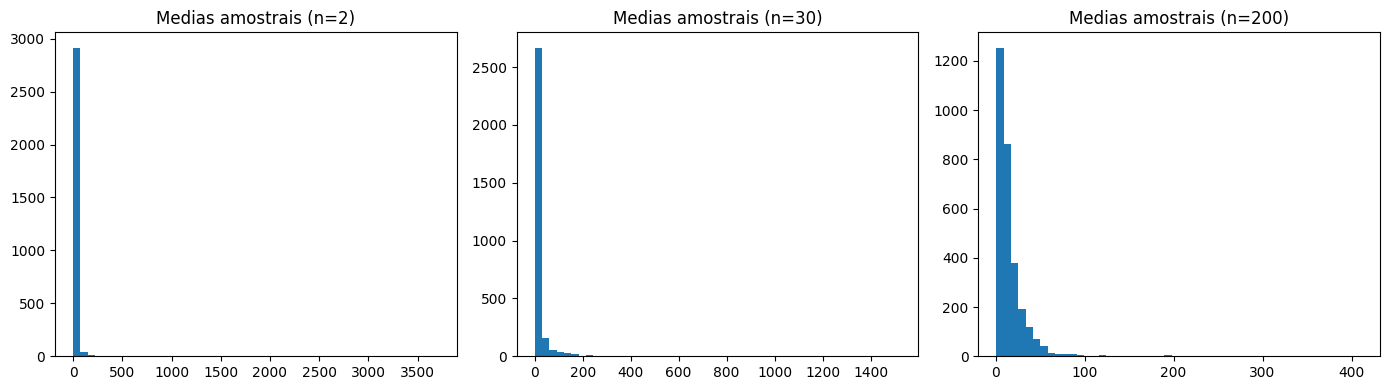

In [12]:
import matplotlib.pyplot as plt

valores = edges7["value_usd_millions"].values
rng = np.random.default_rng(42)

tamanhos_amostra = [2, 30, 200]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, n in zip(axes, tamanhos_amostra):
    medias_amostrais = [
        rng.choice(valores, size=n, replace=True).mean() for _ in range(3000)
    ]
    ax.hist(medias_amostrais, bins=50)
    ax.set_title(f"Medias amostrais (n={n})")

plt.tight_layout()
plt.show()

Com `n=2`, a distribuição das médias ainda carrega a assimetria original. Com `n=200`, ela já se aproxima visivelmente de um sino simétrico — o TCL em ação, apesar da distribuição de origem ser extrema.

### 6.8 Teste A/B conceitual: dois domínios têm a mesma média?

In [13]:
dominio_a, dominio_b = edges7["fcs_domain"].unique()[:2]

grupo_a = edges7.loc[edges7["fcs_domain"] == dominio_a, "value_usd_millions"]
grupo_b = edges7.loc[edges7["fcs_domain"] == dominio_b, "value_usd_millions"]

t_estat, p_valor_ab = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)

print(f"Dominio A: {dominio_a} (media = {grupo_a.mean():.2f})")
print(f"Dominio B: {dominio_b} (media = {grupo_b.mean():.2f})")
print(f"\nEstatistica t: {t_estat:.2f}")
print(f"Valor-p:       {p_valor_ab:.4f}")

Dominio A: C. Visual arts (crafts) / F. Design (media = 46.90)
Dominio B: D. Books and press (media = 3.68)

Estatistica t: 34.33
Valor-p:       0.0000


Em um teste A/B real de negócio, "domínio A" e "domínio B" seriam duas versões de um produto, duas campanhas, dois segmentos — a lógica estatística é idêntica à que acabamos de aplicar a dois domínios de comércio.

## 🧪 Exercícios Práticos — Aula 6

> **Como usar:** resolva cada exercício em uma célula de código abaixo do enunciado. Depois, leve o resultado para uma IA usando o *prompt sugerido*.

---

### Exercício 1 — HHI de um domínio específico ao longo do tempo
**📝 Tarefa:** Filtre `hhi_por_dominio_ano` para um único domínio e trace a evolução do HHI de 2002 a 2024. A concentração sobe, cai, ou oscila?

**🤖 Pergunte à IA:**
> "A série de HHI deste domínio ao longo do tempo foi: [cole os valores]. Isso sugere uma tendência de (re)concentração, dispersão, ou nenhuma tendência clara?"

---

### Exercício 2 — Correlação de Pearson vs. Spearman
**📝 Tarefa:** Calcule também a correlação de **Pearson** entre HHI mediano e Ξ mediano (Célula 12 usou Spearman). Os dois coeficientes são parecidos? Se não forem, o que isso sugere sobre a relação entre as duas variáveis?

**🤖 Pergunte à IA:**
> "Obtive correlação de Pearson = [X] e de Spearman = [Y] para o mesmo par de variáveis. Por que essas duas medidas podem divergir, e qual delas é mais apropriada quando a relação não é linear?"

---

### Exercício 3 — ANOVA com um domínio removido
**📝 Tarefa:** Repita a ANOVA da Célula 16, mas removendo o domínio de maior HHI mediano. O resultado (estatística F, valor-p) muda muito? O que isso sugere sobre a robustez da conclusão?

**🤖 Pergunte à IA:**
> "Minha ANOVA original deu F=[X], p=[Y]. Ao remover o domínio mais concentrado, o resultado mudou para F=[X2], p=[Y2]. Isso enfraquece ou fortalece a conclusão de que os domínios diferem em concentração?"

---

### Exercício 4 — TCL com uma amostra ainda menor
**📝 Tarefa:** Repita a simulação da Célula 18 com `n=1` (ou seja, sem nenhuma agregação). O histograma se parece com os demais? Por quê?

**🤖 Pergunte à IA:**
> "Ao simular médias amostrais com tamanho de amostra n=1, o histograma resultante foi [descreva]. Por que o Teorema Central do Limite não se aplica nesse caso?"

---

### Exercício 5 — Seu próprio teste A/B
**📝 Tarefa:** Escolha dois anos (por exemplo, 2010 e 2020) em vez de dois domínios, e teste se o valor médio exportado mudou significativamente entre eles.

**🤖 Pergunte à IA:**
> "Testei se o valor médio exportado em [ano 1] difere de [ano 2] e obtive p=[X]. Que cuidado adicional eu deveria ter antes de atribuir essa diferença (ou ausência dela) a uma causa econômica específica?"